In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## A single run

In [2]:
#FOLDER = "04-03-26--14_34_00/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

# FOLDER = "26-02-26--11_04_41/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

FOLDER = "05-03-26--14_56_45/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"


data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

### Aggregate global accuracy by round

In [3]:
# data = res['users']
# aggregated = agg_global_accuracy_by_round(data)
#
# aggregated

## Multiple runs

In [4]:
# FOLDER = "26-02-26--11_04_41/"
#
# data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# if FOLDER:
#     data_dir = data_dir / FOLDER
#
# runs = load_runs(data_dir)
#
# # Normalize units: wei → ETH, ratio → %
# runs = normalize_runs(runs)
# res = merge_runs(runs)

## Plots

## Plot: GRS by user

In [5]:
data = res['users']

# data[['grs', 'user_id', 'round']]

vals = grs_by_user(data)

# fig = plot_grs_by_user(vals)

data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds
4,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,4,active,good,bad,88000,7370,1.029028,0.0980,...,3,1.0,3,1.0,False,4,1,1,0,5
10,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,4,active,good,bad,209000,7309,1.057949,0.2155,...,3,1.0,3,1.0,False,4,1,1,0,5
16,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,4,active,bad,bad,655000,5326,0.705299,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
22,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,4,active,bad,bad,837000,1781,0.470200,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
28,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,4,active,bad,bad,879000,1313,0.313466,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5
5,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,5,active,good,freerider,114000,7361,1.035032,0.0980,...,3,1.0,3,1.0,False,4,1,1,0,5
11,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,5,active,good,freerider,231000,7306,1.070217,0.2155,...,3,1.0,3,1.0,False,4,1,1,0,5
17,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,5,active,freerider,freerider,688000,5230,0.713478,0.6552,...,3,1.0,3,1.0,False,4,1,1,0,5
23,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,5,active,freerider,freerider,842000,1795,0.475652,0.8290,...,3,1.0,3,1.0,False,4,1,1,0,5
29,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,5,active,freerider,freerider,872000,1326,0.317101,0.8724,...,3,1.0,3,1.0,False,4,1,1,0,5


## Plot: Model Performance by Global Accuracy for aggregation strategies

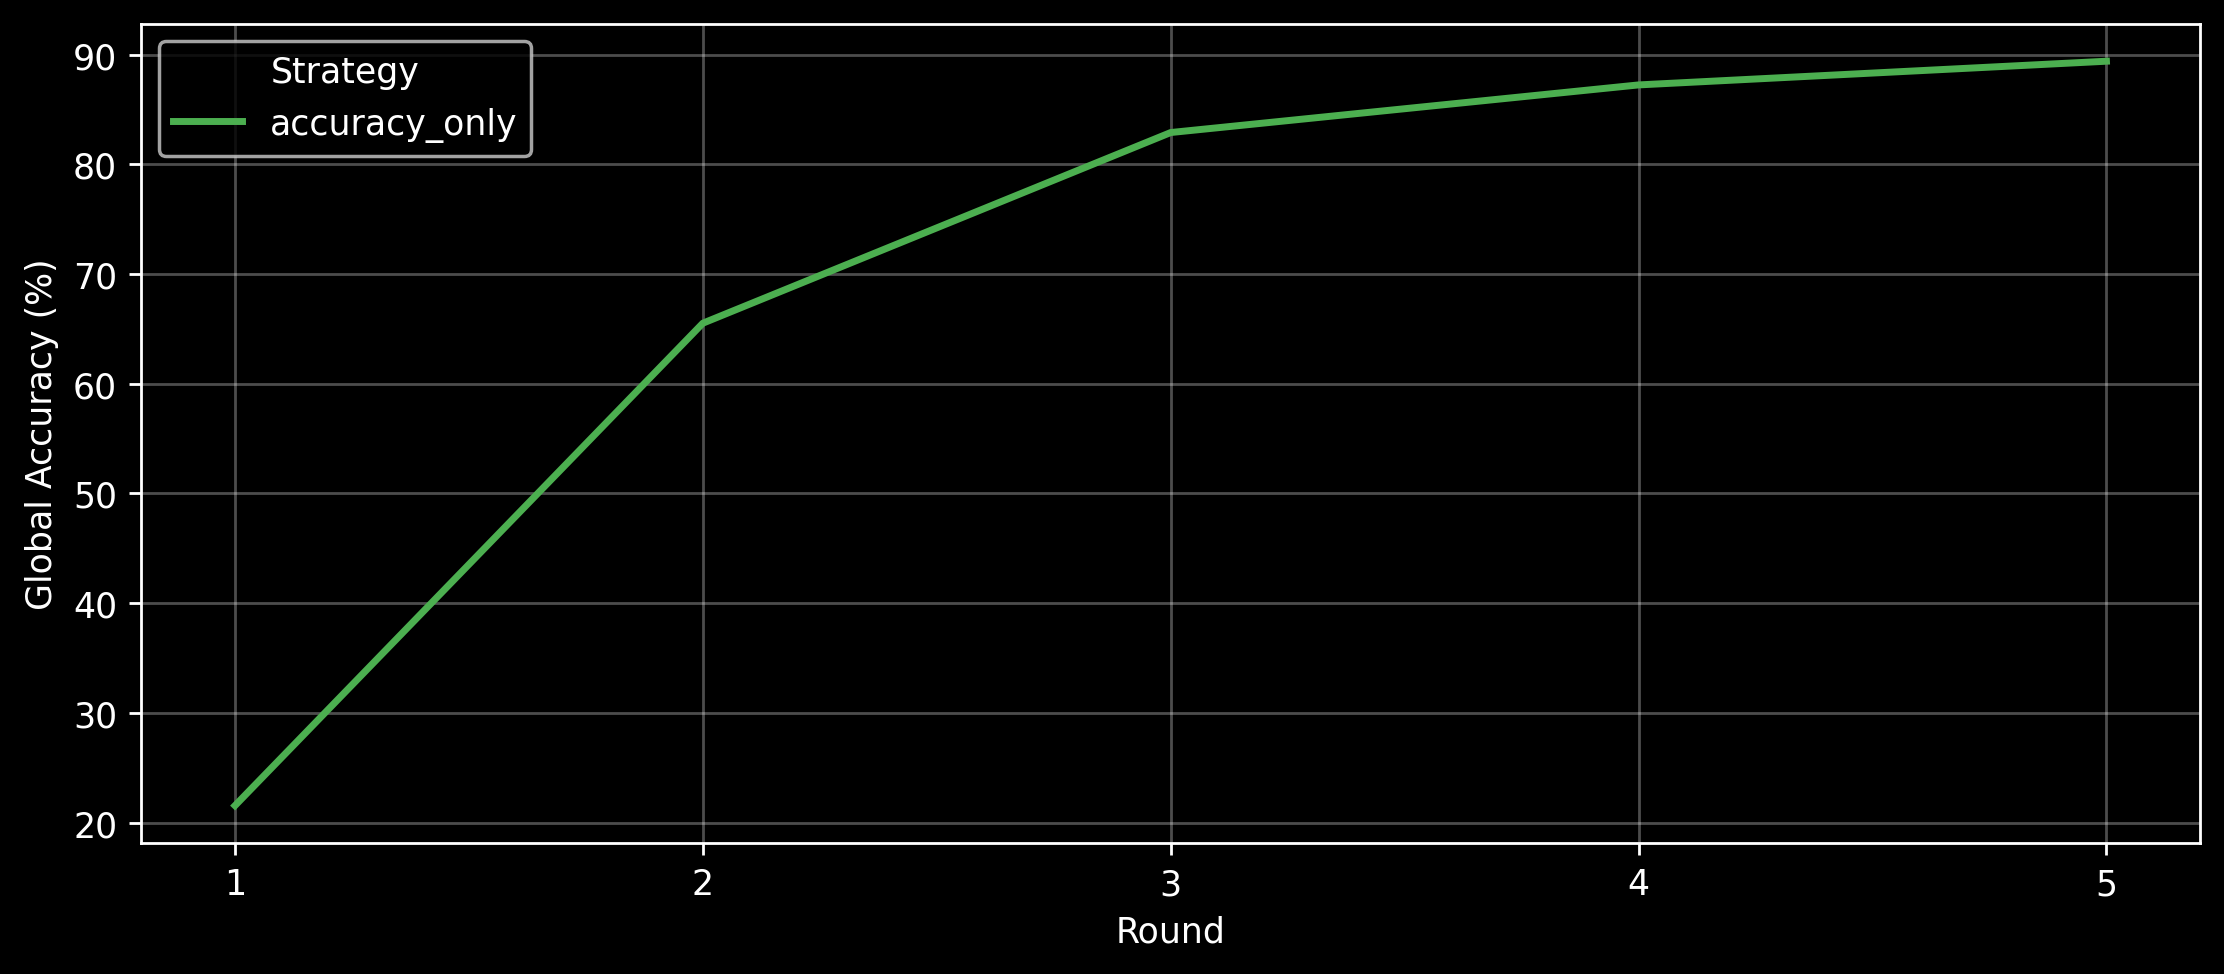

In [6]:
data = res['global']

# It logs self.pytorch_model.accuracy[-1] — so it's the accuracy of the global model evaluated after
# merging all participants' weights each round. That's the true global model performance, distinct from
# individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_accuracy']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_acc_by_aggregation_strategy(data)
fig = plot_global_acc_by_aggregation_strategy(vals)

## Plot: Model Performance by Global Loss for aggregation strategies

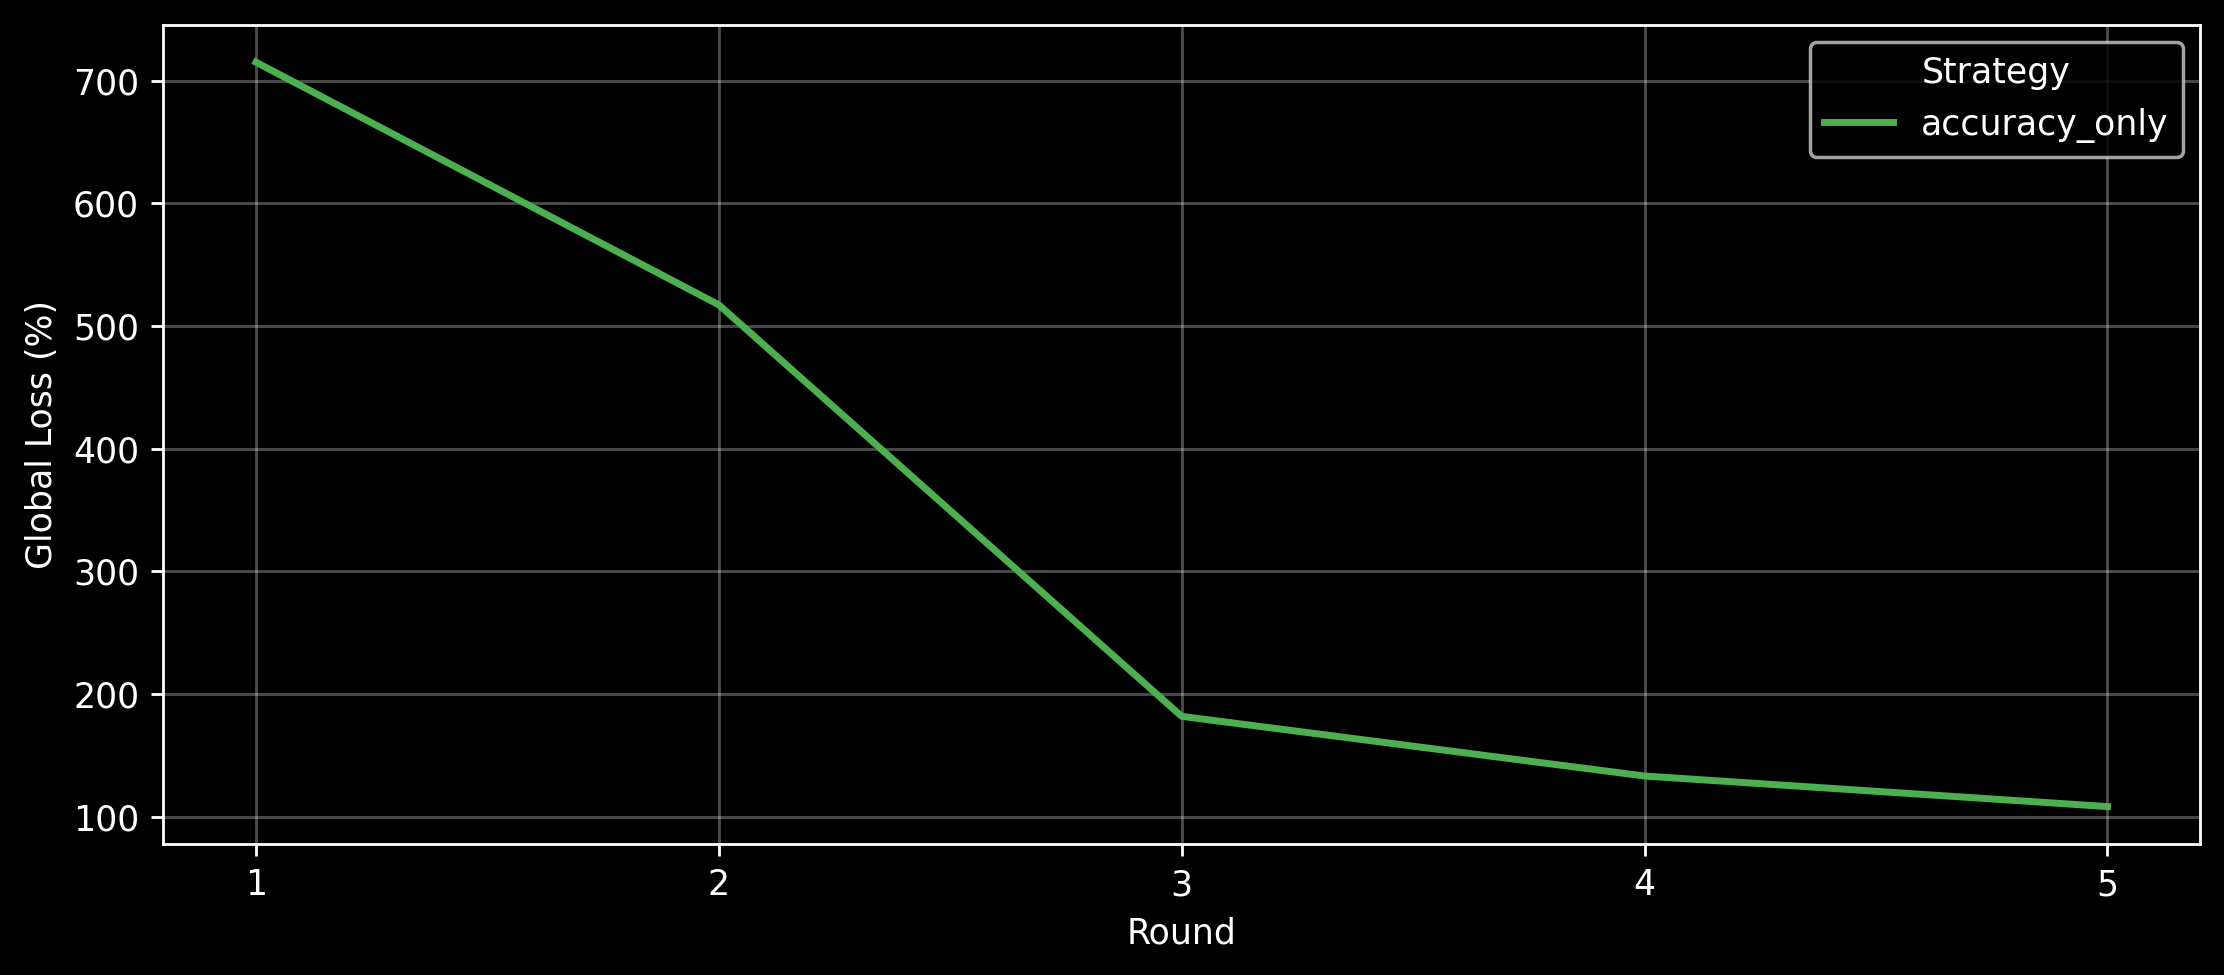

In [7]:
data = res['global']

# ●It logs self.pytorch_model.loss[-1] — so it's the loss of the global model evaluated after
#  merging all participants' weights each round. That's the true global model performance, distinct from
#  individual user accuracies.

# vals = grs_by_user(data)
# data[['round', 'global_loss']]
# data[vals['user_id'].isin([4, 5])].sort_values(['user_id', 'round'])

# data

vals = global_loss_by_aggregation_strategy(data)
fig = plot_global_loss_by_aggregation_strategy(vals)